<a href="https://colab.research.google.com/github/Sarvesh-joshi273/sarvesh/blob/main/sarvesh19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [5]:
df=pd.read_csv("ford.csv")

In [6]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [7]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [8]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [9]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
print(missing_percent)
df = df.dropna()
df = df.drop_duplicates()
print(df.head(10))


model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
dtype: float64
    model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0  Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1   Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2   Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3  Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4  Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5  Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6    Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7  Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8    Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9   Focus  2018  10000       Manual

In [10]:
df.describe()
df["price"].min()
df["price"].max()
df["price"].mean()
df["price"].median()


11288.0

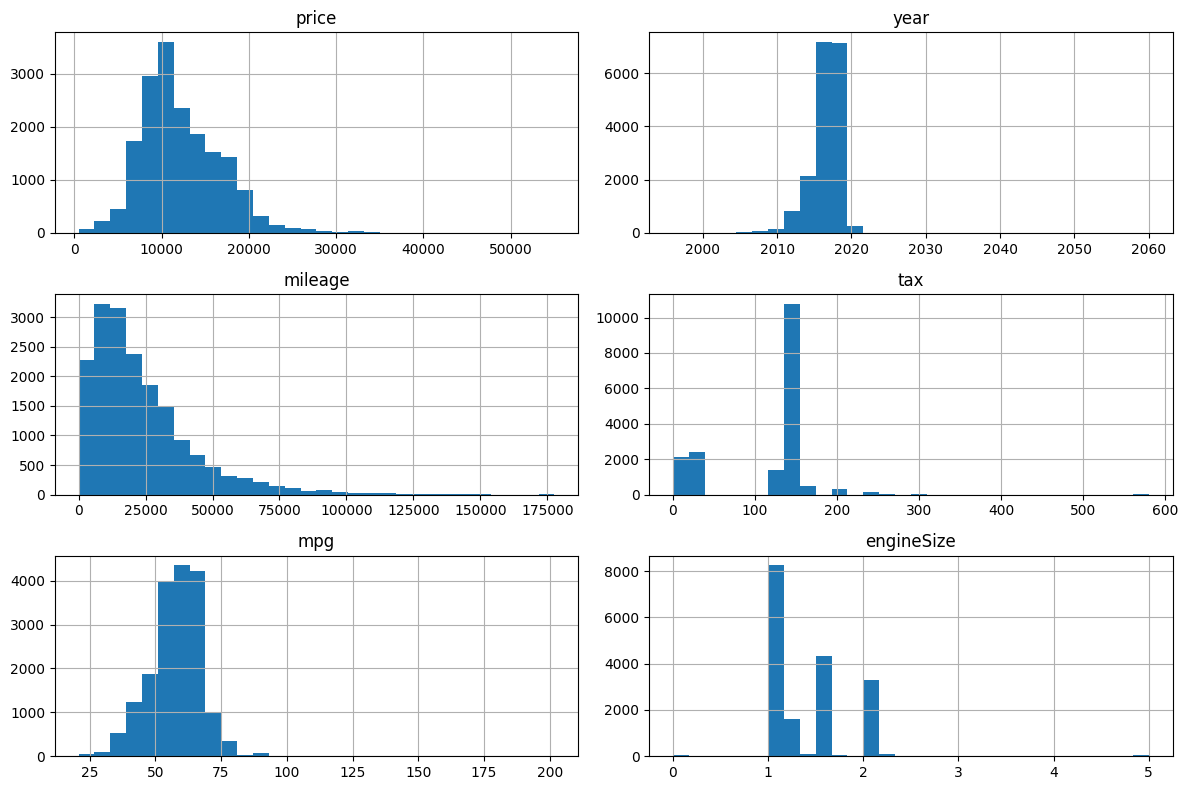

In [12]:
numeric_cols = ["price", "year", "mileage", "tax", "mpg", "engineSize"]
df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()


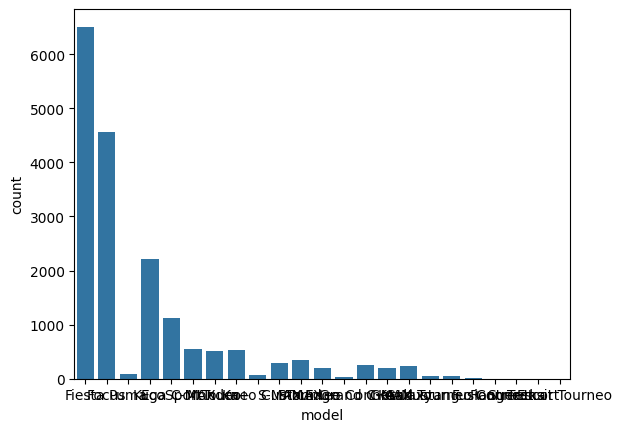

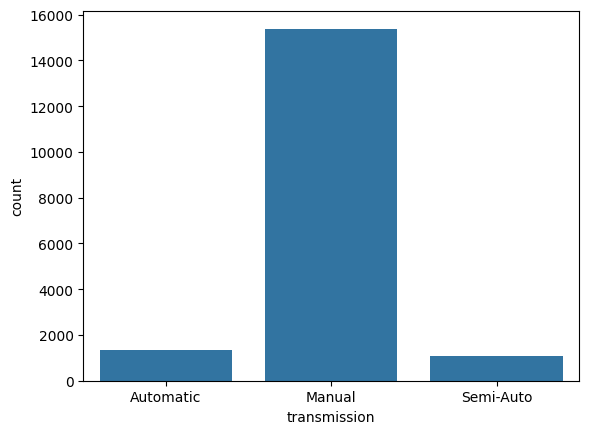

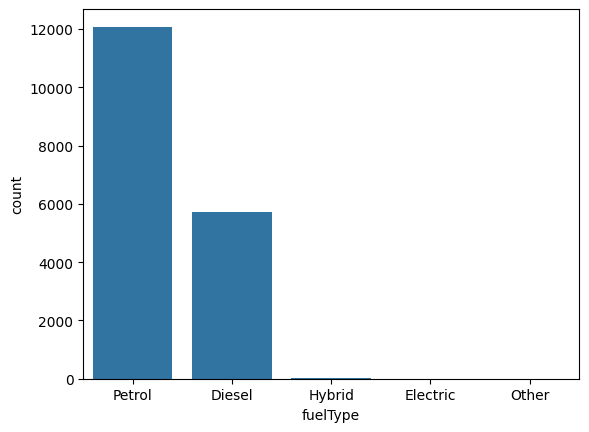

In [16]:
categorical_cols = ["model", "transmission", "fuelType"]
sns.countplot(x="model", data=df)
plt.show()
sns.countplot(x="transmission", data=df)
plt.show()
sns.countplot(x="fuelType", data=df)
plt.show()


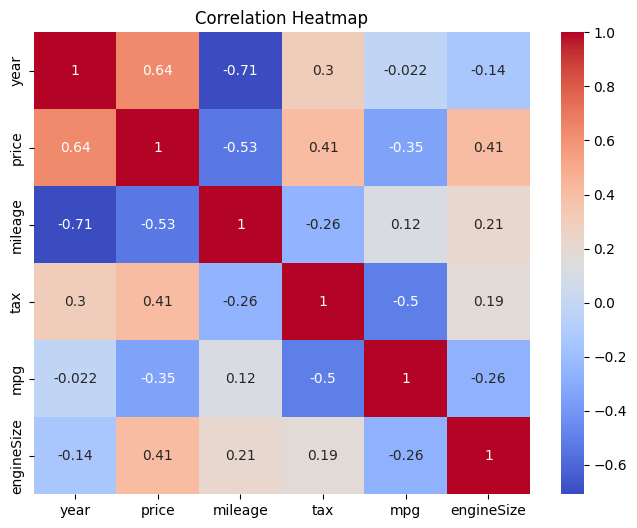

In [20]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
df_encoded = pd.get_dummies(df, columns=["transmission", "fuelType"])

print(df_encoded.filter(like="transmission").head())
print(df_encoded.filter(like="fuelType").head())

   transmission_Automatic  transmission_Manual  transmission_Semi-Auto
0                    True                False                   False
1                   False                 True                   False
2                   False                 True                   False
3                   False                 True                   False
4                    True                False                   False
   fuelType_Diesel  fuelType_Electric  fuelType_Hybrid  fuelType_Other  \
0            False              False            False           False   
1            False              False            False           False   
2            False              False            False           False   
3            False              False            False           False   
4            False              False            False           False   

   fuelType_Petrol  
0             True  
1             True  
2             True  
3             True  
4             True  


In [23]:
X = df[["year", "mileage", "tax", "mpg", "engineSize"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[ 0.06705901 -0.38299351  0.59137991 -0.02059691 -0.81056084]
 [ 0.55439275 -0.73631699  0.59137991 -0.02059691 -0.81056084]
 [ 0.06705901 -0.56261635  0.59137991 -0.02059691 -0.81056084]
 [ 1.0417265  -0.66540511  0.51077747 -1.73785836  0.34532516]
 [ 1.0417265  -1.12774853  0.51077747 -0.90883559 -0.81056084]]
